# Credit Risk & Loan Default Prediction
## Phase 4 — Modeling

**Goal of this notebook.** Build models that estimate each borrower's risk of default, and find out honestly how good they are. We'll compare four things, from simplest to most complex:

1. **Reference points** with no machine learning at all (a coin flip, a one-line rule, and a model using only income and age).
2. **Logistic regression**: a simple, interpretable model that is the industry standard for credit scoring.
3. **Random forest**: many decision trees voting together.
4. **Gradient boosting**: trees built one after another, each fixing the previous ones' mistakes.

**The rule of this phase: the test set stays locked.** This notebook loads only `train.csv`. All comparisons use **cross-validation** inside the training set. The 30,000 test borrowers are not touched until Phase 5.

**The metric: AUC.** *AUC-ROC* answers one question: *"If I pick one borrower who defaulted and one who didn't, how often does the model give the defaulter the higher risk score?"* 0.5 means the model is no better than a coin flip. 1.0 means perfect ranking. AUC is the standard for credit scoring because it judges *ranking* and doesn't depend on where we later draw the approve/reject line, and it isn't fooled by the fact that only ~6.7% of borrowers default.

**What cross-validation is.** We split the training data into 5 equal parts ("folds"). Train on 4, score on the held-out 1, repeat 5 times so every part gets a turn as the mini-exam. The average tells us how the model does on borrowers it hasn't seen, and the spread tells us how stable that is.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import loguniform, randint, uniform
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from src.preprocessing import TARGET

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

train = pd.read_csv("../data/train.csv", index_col=0)
X_train, y_train = train.drop(columns=TARGET), train[TARGET]
print(f"Training set: {X_train.shape[0]:,} borrowers, {X_train.shape[1]} features, default rate {y_train.mean():.2%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}   # model name -> array of 5 cross-validated AUC scores

def evaluate(name, model, X=X_train):
    """Score a model with 5-fold cross-validated AUC and store the result."""
    scores = cross_val_score(model, X, y_train, cv=cv, scoring="roc_auc", n_jobs=5)
    results[name] = scores
    print(f"{name:<45} AUC = {scores.mean():.4f}  (+/- {scores.std():.4f})")
    return scores

Training set: 119,999 borrowers, 20 features, default rate 6.68%


## 1. Reference points: what does "no machine learning" score?

A model only impresses if it beats simple alternatives. Three yardsticks:

- **Coin flip** (always predict the same thing): AUC 0.5 by definition.
- **A one-line rule a credit officer could apply by hand:** rank borrowers by how many times they've been late. No learning involved.
- **A model using only income and age**: the kind of thing you could infer from an application form, without any credit history.

In [2]:
# 1) Coin flip
evaluate("Coin flip (constant prediction)", DummyClassifier(strategy="prior"))

# 2) Hand rule: rank by number of late payments (no fitting at all, so we can score the whole training set directly)
auc_ever = roc_auc_score(y_train, X_train.ever_late)
auc_total = roc_auc_score(y_train, X_train.total_late_payments)
print(f"{'Rule: flag anyone ever late (yes/no)':<45} AUC = {auc_ever:.4f}")
print(f"{'Rule: rank by total late payments':<45} AUC = {auc_total:.4f}")
results["Rule: rank by total late payments"] = np.array([auc_total])

# 3) Income + age only
evaluate("Logistic: income and age only",
         Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]),
         X=X_train[["age", "MonthlyIncome"]])

Coin flip (constant prediction)               AUC = 0.5000  (+/- 0.0000)
Rule: flag anyone ever late (yes/no)          AUC = 0.7518
Rule: rank by total late payments             AUC = 0.7749
Logistic: income and age only                 AUC = 0.6403  (+/- 0.0036)


array([0.63878589, 0.63601981, 0.64407378, 0.63755716, 0.64493853])

## 2. Logistic regression (the interpretable baseline)

Logistic regression gives each feature a weight and adds them up into a risk score. It's transparent: you can read off *which* features push risk up or down, which is why banks have relied on it for decades. Because it is sensitive to feature scales, we put a `StandardScaler` inside a **Pipeline**. Inside cross-validation, the scaler then learns its averages only from the 4 training folds each time. That's the leakage-proofing we promised in Phase 3.

### The class-imbalance decision (chosen approach: `class_weight="balanced"`)
Only ~6.7% of borrowers default. Left alone, a model can under-attend to them. **`class_weight="balanced"`** tells the model that getting a defaulter wrong costs about 14 times more than getting a good borrower wrong (in proportion to how rare they are). **SMOTE** is an alternative that *invents* synthetic defaulters by interpolating between real ones. We compare all three below. SMOTE runs *inside* each cross-validation fold, so synthetic borrowers never leak into the exam fold.

In [3]:
def lr(**kw):
    return Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression(max_iter=2000, **kw))])

evaluate("Logistic: no imbalance handling", lr())
evaluate("Logistic: class_weight='balanced'", lr(class_weight="balanced"))
evaluate("Logistic: SMOTE (comparison)", ImbPipeline([
    ("scale", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(max_iter=2000)),
]))

Logistic: no imbalance handling               AUC = 0.8557  (+/- 0.0061)


Logistic: class_weight='balanced'             AUC = 0.8567  (+/- 0.0061)


Logistic: SMOTE (comparison)                  AUC = 0.8563  (+/- 0.0061)


array([0.85416031, 0.84627759, 0.86293922, 0.85548186, 0.86248332])

**Notice AUC barely moves between the three.** That's expected: AUC judges the *ranking* of borrowers, and reweighting doesn't reorder them much. So where does class weighting matter? It matters when you convert the score into a yes/no decision. Let's see what happens at the default cut-off of 50% risk:

In [4]:
rows = []
for label, model in [("No imbalance handling", lr()), ("class_weight='balanced'", lr(class_weight="balanced"))]:
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=["precision", "recall"], n_jobs=5)
    rows.append({"Model": label, "Recall (share of defaulters caught)": r["test_recall"].mean(),
                 "Precision (share of flagged who really default)": r["test_precision"].mean()})
pd.DataFrame(rows).set_index("Model").round(3)

,Recall (share of defaulters caught),Precision (share of flagged who really default)
Model,,
No imbalance handling,0.164,0.611
class_weight='balanced',0.743,0.216


**This is the payoff.** Without weighting, the model at a 50% cut-off catches very few defaulters, because almost every borrower has less than a 50% chance and so is labeled "good". With balancing it catches many more defaulters, at the price of flagging more good borrowers by mistake (lower precision). Which trade-off is right is a **business** question (how costly is a missed default vs. a wrongly rejected customer?). We'll discuss the threshold properly in Phase 5. For now: we use `class_weight="balanced"` for all models.

## 3. Random forest

A **decision tree** asks a series of yes/no questions ("utilization above 80%? ever late?") to sort borrowers into groups. One tree overfits (memorizes the training data). A **random forest** averages hundreds of slightly different trees, which cancels out their individual quirks. It captures non-straight-line effects and interactions between features (for example, "high utilization *and* young") that logistic regression can't.

**Tuning.** Models have settings (called *hyperparameters*) chosen by us rather than learned. We try a modest number of random combinations with `RandomizedSearchCV`, using cross-validation on the training set only. We keep it small on purpose: the goal is a clear, defensible model rather than the last fraction of a percent of accuracy. Key settings: `min_samples_leaf` (how many borrowers each final group must contain; larger values = simpler trees, less overfitting) and `max_depth` (how many questions deep a tree may go).

In [5]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=250, class_weight="balanced_subsample",
                           random_state=RANDOM_STATE, n_jobs=2),
    param_distributions={
        "max_depth": [6, 8, 10, 14, None],
        "min_samples_leaf": [10, 25, 50, 100, 200],
        "max_features": ["sqrt", 0.3, 0.5],
    },
    n_iter=8, scoring="roc_auc", cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=4, verbose=0,
)
rf_search.fit(X_train, y_train)
print("Best random-forest settings:", rf_search.best_params_)
best_rf = rf_search.best_estimator_
evaluate("Random forest (tuned)", best_rf)

Best random-forest settings: {'min_samples_leaf': 100, 'max_features': 'sqrt', 'max_depth': None}


Random forest (tuned)                         AUC = 0.8629  (+/- 0.0059)


array([0.86100677, 0.85325042, 0.86776046, 0.86229235, 0.87020252])

## 4. Gradient boosting

Instead of averaging independent trees, **gradient boosting** builds trees one after another, each one focusing on the borrowers the previous trees got wrong. It is usually the strongest model on tables of numbers like this one. We use scikit-learn's `HistGradientBoostingClassifier`, which works the same way as the well-known XGBoost and LightGBM libraries. (Those two need an extra system library on some platforms, such as macOS; this one ships with scikit-learn, which makes the project easier to reproduce.) Key settings: `learning_rate` (how big a correction each new tree makes) and `max_leaf_nodes` / `min_samples_leaf` (how complex each tree may be), plus `l2_regularization` (a penalty against over-complexity).

In [6]:
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight="balanced", early_stopping=True,
                                   validation_fraction=0.1, n_iter_no_change=20,
                                   max_iter=500, random_state=RANDOM_STATE),
    param_distributions={
        "learning_rate": loguniform(0.02, 0.2),
        "max_leaf_nodes": [8, 15, 31, 63],
        "min_samples_leaf": [20, 50, 100, 200],
        "l2_regularization": loguniform(1e-3, 10),
    },
    n_iter=12, scoring="roc_auc", cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=4, verbose=0,
)
hgb_search.fit(X_train, y_train)
print("Best gradient-boosting settings:", hgb_search.best_params_)
best_hgb = hgb_search.best_estimator_
evaluate("Gradient boosting (tuned)", best_hgb)

Best gradient-boosting settings: {'l2_regularization': np.float64(0.00541524411940254), 'learning_rate': np.float64(0.04029695576831731), 'max_leaf_nodes': 15, 'min_samples_leaf': 20}


Gradient boosting (tuned)                     AUC = 0.8642  (+/- 0.0058)


array([0.86305336, 0.85459239, 0.86932696, 0.8632084 , 0.87091974])

## 5. Side-by-side comparison

In [7]:
order = ["Coin flip (constant prediction)", "Logistic: income and age only", "Rule: rank by total late payments",
         "Logistic: class_weight='balanced'", "Random forest (tuned)", "Gradient boosting (tuned)"]
table = pd.DataFrame({
    "Mean AUC": [results[k].mean() for k in order],
    "Std across folds": [results[k].std() if len(results[k]) > 1 else np.nan for k in order],
}, index=order).round(4)
table

,Mean AUC,Std across folds
Coin flip (constant prediction),0.5000,0.0000
Logistic: income and age only,0.6403,0.0036
Rule: rank by total late payments,0.7749,NaN
Logistic: class_weight='balanced',0.8567,0.0061
Random forest (tuned),0.8629,0.0059
Gradient boosting (tuned),0.8642,0.0058


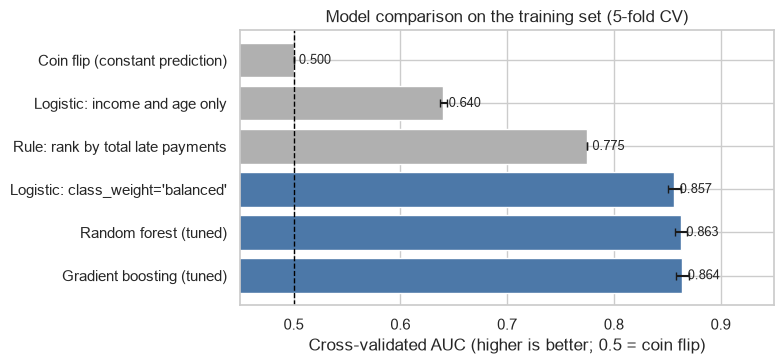

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = ["#B0B0B0", "#B0B0B0", "#B0B0B0", "#4C78A8", "#4C78A8", "#4C78A8"]
means = table["Mean AUC"].values
errs = table["Std across folds"].fillna(0).values
ax.barh(order[::-1], means[::-1], xerr=errs[::-1], color=colors[::-1], capsize=3)
ax.axvline(0.5, color="black", ls="--", lw=1)
for i, v in enumerate(means[::-1]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.45, 0.95)
ax.set_xlabel("Cross-validated AUC (higher is better; 0.5 = coin flip)")
ax.set_title("Model comparison on the training set (5-fold CV)")
plt.tight_layout()
plt.savefig("../reports/04_model_comparison.png", dpi=150)
plt.show()

## 6. How big are the differences, really?

The models score 0.857, 0.863 and 0.864. Are the gaps real, or just noise from which borrowers landed in which fold? Every model was scored on *exactly the same five folds*, so we can compare them fold by fold: if a model wins in all five, the edge is consistent.

In [9]:
lr_bal = results["Logistic: class_weight='balanced'"]
rf_s = results["Random forest (tuned)"]
gb_s = results["Gradient boosting (tuned)"]
paired = pd.DataFrame({
    "Boosting minus logistic": gb_s - lr_bal,
    "Random forest minus logistic": rf_s - lr_bal,
    "Boosting minus random forest": gb_s - rf_s,
}, index=[f"fold {i}" for i in range(1, 6)])
paired.loc["mean"] = paired.mean()
paired.round(4)

,Boosting minus logistic,Random forest minus logistic,Boosting minus random forest
fold 1,0.0084,0.0063,0.0020
fold 2,0.0077,0.0063,0.0013
fold 3,0.0059,0.0043,0.0016
fold 4,0.0075,0.0065,0.0009
fold 5,0.0081,0.0074,0.0007
mean,0.0075,0.0062,0.0013


## 7. Refit the finalists on the full training set and save them

Cross-validation trained each model on only 80% of the training data at a time. Now we refit each finalist on **all** of the training data (the tuned search objects have already done this for the two tree models) so Phase 5 can evaluate them once, on the locked test set. We also take a first look at what the logistic regression learned.

In [10]:
import os
os.makedirs("../models", exist_ok=True)

final_lr = lr(class_weight="balanced").fit(X_train, y_train)
joblib.dump(final_lr, "../models/logistic_regression.joblib")
joblib.dump(best_rf, "../models/random_forest.joblib")
joblib.dump(best_hgb, "../models/gradient_boosting.joblib")
print("Saved: logistic_regression, random_forest, gradient_boosting (in models/)")

coefs = pd.Series(final_lr.named_steps["lr"].coef_[0], index=X_train.columns).sort_values()
print()
print("Logistic regression weights (features were standardized, so sizes are comparable).")
print("Positive = raises predicted default risk, negative = lowers it:")
print(coefs.round(3).to_string())

Saved: logistic_regression, random_forest, gradient_boosting (in models/)

Logistic regression weights (features were standardized, so sizes are comparable).
Positive = raises predicted default risk, negative = lowers it:
past_due_code_flag                     -0.786
age                                    -0.280
debt_ratio_unreliable_flag             -0.184
MonthlyIncome                          -0.093
dependents_missing_flag                -0.006
NumberOfDependents                      0.021
NumberOfTime30-59DaysPastDueNotWorse    0.039
DebtRatio                               0.090
NumberRealEstateLoansOrLines            0.109
util_25_50                              0.120
income_missing_flag                     0.134
NumberOfOpenCreditLinesAndLoans         0.143
util_over_limit                         0.171
util_50_75                              0.204
NumberOfTime60-89DaysPastDueNotWorse    0.254
total_late_payments                     0.285
RevolvingUtilizationOfUnsecuredLines    0.

**Reading the weights.**

- The largest *upward* pushes are the number of 90+ day late payments, the `ever_late` flag, and utilization (the 75-100% band and the raw utilization number). The strongest *downward* push among the ordinary features is age (older = safer). This agrees with the Phase 2 story.
- **Do not read any single weight in isolation.** Several features overlap: `total_late_payments`, `ever_late` and the three separate late-payment counts all measure payment history, and utilization appears both as a number and as bands. When features overlap, the model splits the credit between them arbitrarily (this is the multicollinearity we flagged in Phase 2). A weight of 0.04 on "30-59 days late" does *not* mean lateness of that kind is unimportant; its information is being carried by the other columns. Phase 5 uses a cleaner method (permutation importance / SHAP) to rank the drivers.
- **A weight that looks wrong, and probably why.** `past_due_code_flag` has a large *negative* weight, although those 269 borrowers default about 55% of the time. Most likely reason: for them we set the three late-payment counts to the largest genuine values (13, 11 and 17), which pushes their `total_late_payments` very high and would over-predict their risk; the flag then pulls the score back down. This is a good example of why weights should be read as a package, not one at a time.

## Phase 4 summary (plain English)

| Model | Cross-validated AUC |
|---|---|
| Coin flip | 0.500 |
| Income and age only | 0.640 |
| One-line rule: rank by total late payments | 0.775 |
| **Logistic regression** (balanced weights) | **0.857** |
| **Random forest** (tuned) | **0.863** |
| **Gradient boosting** (tuned) | **0.864** |

- Payment history alone (a rule anyone could apply by hand) reaches AUC 0.775. Combining all features in a logistic regression lifts that to 0.857, a much bigger step than anything that follows.
- The more complex models add only about **0.006-0.008 AUC**. That edge is consistent (boosting beats logistic regression in all 5 folds), but small: in practice, roughly 0.75% more defaulter/non-defaulter pairs ranked correctly. Boosting and random forest are effectively tied.
- Choosing `class_weight="balanced"` did not change AUC (0.856 vs 0.857 without it), but it changed what the model does at a 50% cut-off: it catches about **74%** of defaulters instead of **16%**, at the cost of precision falling from 61% to 22%. Which balance is right is a business call, and Phase 5 handles it.
- SMOTE (synthetic defaulters) gave no advantage over simple class weights (AUC 0.856), so we kept the simpler approach.

### Caveats
- The two tree models were *tuned* on the training data, while logistic regression wasn't, so their cross-validated scores are slightly flattering. The locked test set in Phase 5 is the fair judge.
- Cross-validation estimates performance on new borrowers *from the same population and period*. It says nothing about a different bank, country or economic climate.